# Linear Regression

<!-- + 회귀모형은 지도학습 중 예측 문제에 사용하는 알고리즘이다.
+ 회귀모델은 연속적인 타깃 변수를 예측하는데 사용된다.
+ 변수 간의 관계를 이해하거나 트렌드를 분석하고 예측할 수 있다.  -->

## 단순 선형회귀분석 연습

### 패키지 불러오기

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn import datasets
from jupyterthemes import jtplot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

jtplot.style(theme='grade3', grid=False)
mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)

### 데이터 불러오기
+ `sklearn.datasets`안에는 머신러닝 학습을 위한 빌트인(built-in) 데이터 셋들이 존재한다.
  + load_boston: 보스톤 집값 데이터
  + load_iris: 아이리스 붓꽃 데이터
  + load_diabetes: 당뇨병 환자 데이터
  + load_digits: 손글씨 데이터
  + load_linnerud: multi-output regression 용 데이터
  + load_wine: 와인 데이터
  + load_breast_cancer: 위스콘신 유방암 환자 데이터<br>
+ 그 중에 `당뇨병 환자 데이터`를 활용하여 단순 선형 회귀분석을 수행하고자 한다.

In [ ]:
# sklearn에 저장된 데이터셋 불러오기
data = datasets.load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

데이터가 딕셔너리 형태와 비슷하게 구성되어 있으므로 어떤 key를 가지는지 확인해본다.

In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

구성된 key들은 다음과 같다.
+ data: 샘플 데이터, Numpy 배열로 이루어져 있다.
+ target: Label 데이터, Numpy 배열로 이루어져 있다.
+ feature_names: Feature 데이터의 이름
+ target_names: Label 데이터의 이름
+ DESCR: 데이터 셋의 설명
+ filename: 데이터 셋의 파일 저장 위치 (csv)  

여기서 data, target, feature_names 세 가지 key만 사용한다.

In [ ]:
# 데이터프레임으로 바꿔주기
df = pd.DataFrame(data['data'], columns=data['feature_names'])
df['target'] = data['target']
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


여기서 `target`은 당뇨병 수치를 나타내며, `feature`는 `age, sex, bmi, ...` 이다.  
단순 선형회귀분석을 수행하기 위해 `bmi(체질량지수)`와 `target(당뇨병 수치)` 사이에 어떤 관계가 있는지 살펴본다.

### 상관성 파악

1. 산점도

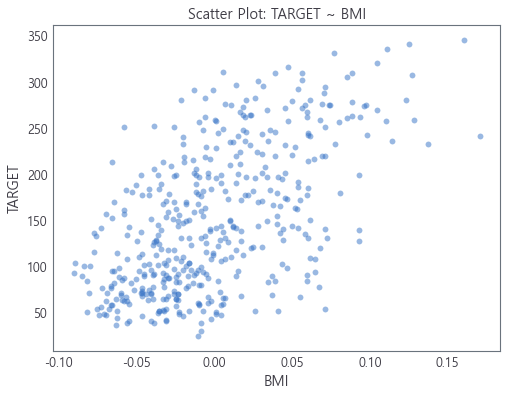

In [ ]:
X = df["bmi"]  # feature
Y = df['target']  # target

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, alpha=0.5)
plt.title('Scatter Plot: TARGET ~ BMI')
plt.xlabel('BMI')
plt.ylabel('TARGET')
plt.show()

+ matplotlib에서 제공하는 `scatter()`를 통해 산점도를 그린 결과이다.
+ 두 변수 사이에 양의 선형관계가 있는 것 처럼 보인다.

2. 상관계수

In [ ]:
np.corrcoef(X, Y).round(3)

array([[1.   , 0.586],
       [0.586, 1.   ]])

+ 상관계수는 -1과 1사이의 값을 가지며 0일 경우에는 두 변수 간의 선형관계가 전혀 없다는 것을 뜻한다.
+ BMI(체질량지수)와 TARGET(당뇨병수치)의 상관계수는 0.586으로 두 변수 사이에 양의 선형관게가 있다고 할 수 있다.

### 모델링
추정하고자 하는 단순 선형회귀모형은 아래와 같다.
```python
y = b0 + b1*x + e
```
sklearn에서 제공하는 linear_model의 LinaeRegression을 사용하여 회귀분석을 수행한다.

In [ ]:
# step1. 모델 선언
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
X = df['bmi'].values
X[:5]

array([ 0.06169621, -0.05147406,  0.04445121, -0.01159501, -0.03638469])

In [ ]:
Y = df['target'].values
Y[:5]

array([151.,  75., 141., 206., 135.])

여기서 주의해야 할 점은 X와 Y 차원을 2d array로 바꿔줘야 한다.

In [ ]:
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)

In [ ]:
X[:5], Y[:5]

(array([[ 0.06169621],
        [-0.05147406],
        [ 0.04445121],
        [-0.01159501],
        [-0.03638469]]),
 array([[151.],
        [ 75.],
        [141.],
        [206.],
        [135.]]))

In [ ]:
# step2. 데이터 적합
lr.fit(X, Y)

LinearRegression()

In [ ]:
# step3. 추정된 회귀계수(b0, b1) 확인
print(lr.coef_[0])  # 기울기 b1
print(lr.intercept_)  # 상수항 b0

[949.43526038]
[152.13348416]


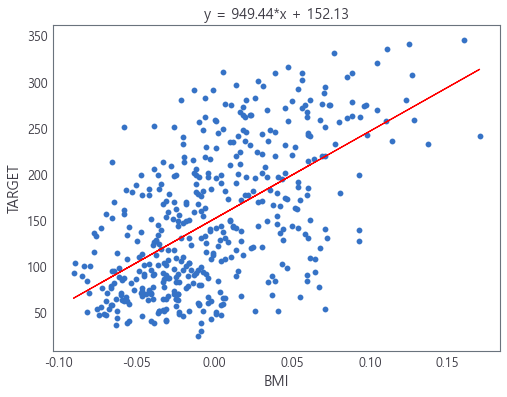

In [ ]:
# step4. 모델링 결과 시각화
import matplotlib.pyplot as plt
Y2 = lr.coef_[0]*X + lr.intercept_

plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.plot(X, Y2, color='red')
plt.title(
    "y = {:.2f}*x + {:.2f}".format(float(lr.coef_[0]), float(lr.intercept_)))
plt.xlabel("BMI")
plt.ylabel("TARGET")
plt.show()

+ 두 변수 관계를 회귀식으로 표현하면 `Target = 949.4*BMI + 152.1`이다.
+ BMI수치가 1단위 증가할 때 Target(당뇨병 수치)가 949.4 만큼 증가한다.

### 회귀모형의 검정

이 회귀식이 통계적으로 유의한지, 변수가 유의하게 영향을 미치는 지, 그리고 얼만큼의 설명력을 가지는지 등의 여부를 확인해야 한다.

1. F-statistic
 + 도출된 회귀식이 통계적으로 의미가 있는지 파악

2. p-Value
 + 각 변수가 종속변수에 미치는 영향이 유의한지 파악

3. 결정계수
 + 회귀직선에 의하여 설명되는 변동이 총변동 중에서 차지하고 있는 상대적인 비율이 얼마인지 나타냄  
</br>
</br>

이번에는 `satasmodels` 패키지를 통해 위에 나온 3가지 모두 확인해본다.


In [ ]:
import statsmodels.api as sm

df1 = df[['target', 'bmi']]

dfy = df1[["target"]]
dfX = sm.add_constant(df[["bmi"]])
model = sm.OLS(dfy, dfX)
result = model.fit()

In [ ]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Wed, 12 Oct 2022   Prob (F-statistic):           3.47e-42
Time:                        14:07:05   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.0

+ 결과를 보면 잔차에 대한 정보, 회귀계수에 대한 정보, R제곱, 검정통계량 F0 값과 P-value 값 등 자세하게 출력된 것을 확인할 수 있다. <br><br>
  + F-statistic의 p-value 값은 Prob(F-statistic)으로 표현되는데, 이는 3.47e-42로 0.05보다 작으므로 이 회귀식은 회귀분석 모델 전체에 대해 통계적으로 의미가 있다고 볼 수 있다. <br><br>
  + coef와 변수 x1의 p-value 값을 확인할 수 있다. 여기서 x1은 bmi이고 이 변수의 p-value가 0.000으로 0.05보다 작으므로 target을 설명하는데 유의하다고 판단할 수 있다. <br><br>
  + R-squared와 Adj. R-squared가 표기되어 있는데, 값이 0.34정도로 이는 34%만큼의 설명력을 가진다고 판단할 수 있다.


### 잔차검정
잔차분석은 회귀모형에 대한 가정(정규성, 등분산성, 독립성)을 충족하는지에 대한 검정, 이상치가 개입하는지에 대한 검정을 하는 절차이다.
<!-- > + 회귀분석을 수행하기 위한 가정 -->
> + 선형성: 독립변수와 종속변수는 선형관계에 있어야한다.
> + 정규성: 잔차는 평균이 0이고, 분산이 시그마제곱인 정규분포를 따른다.
> + 등분산성: 잔차는 동일한 분산을 가져야한다.
> + 독립성: 독립변수가 여러 개인 경우, 서로 독립이다.


+ __모형의 선형성__  
  + 예측값(fitted)과 잔차(residual)를 비교
  + 모든 예측값에서 가운데 점선에 맞추어 잔차가 비슷하게 있어야 한다.
  + 빨간 실선은 잔차의 추세를 나타낸다.
  + 빨간 실선이 점선에서 크게 벗어난다면 예측값에 따라 잔차가 크게 달라진다는 것으로 선형성이 없다는 것이다.

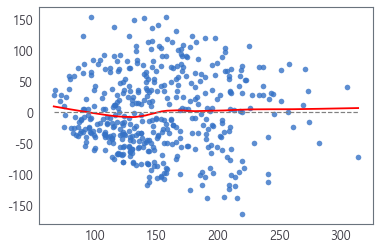

In [ ]:
fitted = result.predict(dfX)
residual = dfy['target'] - fitted

sns.regplot(fitted, residual, lowess=True, line_kws={'color': 'red'})
plt.plot([fitted.min(), fitted.max()], [0, 0], '--', color='grey')

+ __잔차의 정규성__
  + 잔차가 정규분포를 따른다는 가정을 한다.
  + Q-Q Plot로 확인할 수 있다.
  + 잔차가 정규분포를 띄면 Q-Q Plot에서 점들이 점선을 따라 배치되어 있어야 한다.

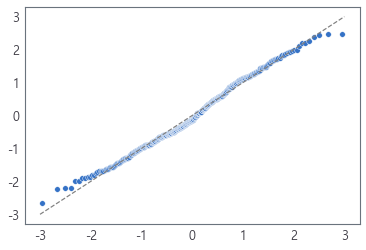

In [ ]:
import scipy.stats

sr = scipy.stats.zscore(residual)
(x, y), _ = scipy.stats.probplot(sr)
sns.scatterplot(x, y)
plt.plot([-3, 3], [-3, 3], '--', color='grey')

In [ ]:
# ShapiroResult(statistic=0.9450905919075012, pvalue=0.02152460627257824)
scipy.stats.shapiro(residual)

ShapiroResult(statistic=0.9903566241264343, pvalue=0.005417970009148121)

+ __잔차의 등분산성__
  + 회귀모형을 통햬 예측된 값이 어떻든지, 모든 값들에 대하여 잔차의 분산이 동일하다는 가정이다.
  + 아래 그래프는 예측값(X축)에 따라 잔차가 어떻게 달라지는지 보여준다.
  + 빨간색 실선이 수평선에 가까울수록 등분산성이 있다는 것이다.

<AxesSubplot:>

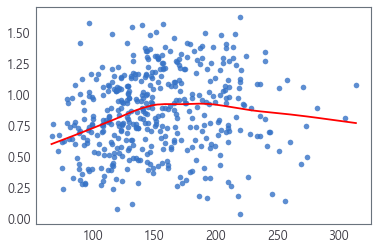

In [ ]:
sns.regplot(fitted, np.sqrt(np.abs(sr)),
            lowess=True, line_kws={'color': 'red'})

+ __잔차의 독립성__
  + Result.summary의 Durbin-Watson(더빈왓슨, DW검정)으로 확인한다.
  + DW검정은 잔차의 독립성을 확인할 수 있는 수치이다. 0이면 잔차들이 양의 자기상관을 갖고, 2이면 자기상관이 없는 독립성을 갖고, 4이면 잔차들이 음의 자기상관을 갖는다고 해석한다.
  + 보통 1.5 ~ 2.5사이이면 독립으로 판단하고 회귀모형이 적합하다는 것을 의미한다. DW검정값이 0 또는 4에 가깝다는 것은 잔차들이 자기상관을 가지고 있다는 의미이고, 이는 t값, F값, R제곱을 실제보다 증가시켜 실제로 유의미하지 않은 결과를 유의미한 결과로 왜곡하게 된다.

In [ ]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Wed, 12 Oct 2022   Prob (F-statistic):           3.47e-42
Time:                        14:07:06   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.0

  + 위 회귀분석에서 더빈왓슨검정(Durbin-Watson)의 값이 1.848이므로 독립성이 있다고 판단할 수 있다.

## python 함수

### 결측 처리: fillna
```python
DataFrame.fillna(value=None, method=None, axis=None, inplace=None)

# value: 결측 데이터에 채울 값 입력
# method:  데이터를 채우는 방식을 지정
    # bfill/backfill: 이후 데이터로 채움
    # pad/ffill: 이전 데이터로 채움
# axis
    # 0 or "index": 가로 기준 축 (Row별)
    # 1 or "coulumns": 세로 기준 축 (Column별)
# inplace: 처리 후 기존 데이터 수정
```

### Dummy 변수 생성: get_dummies
```python
DataFrame.get_dummies(data, prefix=None, prefix_sep='_')

# data: 더미변수 생성 데이터
# prefix: 생성될 더미변수의 접두어. 예) prefix="var" → var1, var2, ...
# prefix_sep: 접두어 뒤의 구분자. 예) prefix_sep="_" → var_1, var_2, ...
```

### 데이터 분할: train_test_split
```python
sklearn.model_selection.train_test_split(test_size=0.25, shuffle=True, random_state=None)

# test size: test 데이터 크기 지정(0~1)
# train_size: train 데이터 크기 지정(0~1)
# shuffle: 데이터 분리 전 데이터 혼합(섞음) 여부 지정
# random_state: 초기 자료 선택 기준, 값에 따라 선택되는 데이터가 달라짐
```

### 모델 훈련: fit
```python
model.fit(X,Y)

# X, Y: 훈련용(train) X 및 y 데이터
```

### 모델 적용: predict
```python
model.predict(X)

# X: 평가 또는 시험용(test) 데이터. 결과로 예측값(y) 제공
```

### 모델 최적 파라메터 탐색: GridSearchCV
+ 공식문서 [바로가기](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

```python
sklearn.model_selection.GridSearchCV(estimator, param_grid, scoring, n_jobs=None, ...)

# estimator: 적용 모델 지정
# param_grid: 탐색 대상 파라미터별 입력 값 지정. 적용 모델별 파라미터 지정
# scoring
    # accuracy: (분류) 모델의 정분륭율
    # f1: (분류) 정밀도(precision)과 재현율(recall) 지수를 이용한 정확도 지수
    # ... 참고 ...
    # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
# n_jobs: 병렬 처리를 위한 core 수 지정
```

### 상관계수 계산: pandas.DataFrame.corr
```python
pandas.DataFrame.corr(method='pearson', min_periods=1)

# method: 상관계수 계산 기준
    # pearson: 피어슨 상관계수 (연속형 data)
    # kendall: 켄달 타우 상관계수 (concordant pair data)
    # spearman: 스피어만 순위 상관계수 (순위 data)
 # min_periods: 상관계수 산출을 위한 최소 데이터 수
```

# Reference
+ [귀무가설과 대립가설이란?](https://blog.naver.com/angryking/222423853501)
+ [Linear Regression / 선형 회귀분석](https://kkokkilkon.tistory.com/77)
+ [잔차분석](https://ysyblog.tistory.com/120)